# 20 — Energy function: real vs. shuffled data (5,000-user cohort)

Standalone notebook, kept separate from 13b/17/18/19 on purpose. Neither `e₊`'s training (`13b_encodingB_personality_training.ipynb`) nor `e₋`'s training (`19_hyperbolic_entropy_5k.ipynb`) ever computes the RBM's energy function explicitly — CD-1 is implemented directly from the analytically-derived update rule, which is standard practice, but it means there is no `E(v,h)` anywhere in this project's code until this notebook.

**Scope note**: per-epoch weight snapshots were never saved during training (only the final trained `W`/`b_h`), so an energy-vs-training-epoch curve cannot be reconstructed after the fact. What this notebook does instead: use the final trained weights for `e₊` and `e₋` and compare the energy of **real** rating patterns against **shuffled** ones — a trained model should assign real, coherent patterns lower energy (higher probability) than scrambled ones. That's a meaningful, honest check given what was actually saved.

**Energy function used** (matches this project's actual RBM implementation — no visible-layer bias term exists in `train_rbm`, only `W` and `b_h`):

$$E(v,h) = -v^\top W h - b_h^\top h$$

## Part 0 — Setup

Load both channels' trained weights (no retraining) plus the data needed to build real and shuffled visible vectors.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

data_dir = root / "data"
proc = root / "data" / "processed"
out_dir = root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

RATING_LEVELS = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0], dtype=np.float64)
K = len(RATING_LEVELS)


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60.0, 60.0)))


# e+ (real part) -- already trained in 13b, no retrain
W_plus = np.load(proc / "rbmB1_weights_5k.npy")
bh_plus = np.load(proc / "rbmB1_bias_hidden_5k.npy")
channelB1 = np.load(proc / "channelB1_softmax.npy", mmap_mode="r")

# e- (deviation) -- already trained in notebook 19, no retrain
W_minus = np.load(proc / "rbmDminus_weights_5k.npy")
bh_minus = np.load(proc / "rbmDminus_bias_hidden_5k.npy")
channelDminus = np.load(proc / "channelDminus_5k.npy", mmap_mode="r")

mask = np.load(proc / "mask.npy", mmap_mode="r")
cohort_user_ids = np.load(proc / "cohort_user_ids.npy").astype(int)
movie_vocab = np.load(proc / "movie_vocab.npy").astype(int)
n_users, n_movies = mask.shape
n_hidden = bh_plus.shape[0]

print(f"e+ : W {W_plus.shape}  bh {bh_plus.shape}")
print(f"e- : W {W_minus.shape}  bh {bh_minus.shape}")
print(f"n_users={n_users:,}  n_movies={n_movies:,}  n_hidden={n_hidden}  K={K}")
print("No visible-layer bias in either channel (train_rbm never defines b_v) -- E(v,h) = -v^T W h - b_h^T h")

e+ : W (131290, 128)  bh (128,)
e- : W (131290, 128)  bh (128,)
n_users=5,000  n_movies=13,129  n_hidden=128  K=10
No visible-layer bias in either channel (train_rbm never defines b_v) -- E(v,h) = -v^T W h - b_h^T h


## Part 1 — Energy function

$$E(v,h) = -v^\top W h - b_h^\top h$$

For a batch: $E_i = -\sum_k (v_i W)_k h_{ik} - b_h^\top h_i$. Implemented directly from `W`/`b_h` as actually saved -- no visible bias term, matching the real `train_rbm` code in 13b/19.

In [2]:
def energy(v, h, W, bh):
    """E(v,h) = -v^T W h - b_h^T h, batched over rows of v/h."""
    return -((v @ W) * h).sum(axis=1) - (h @ bh)


def sample_h(v, W, bh, rng):
    h_prob = sigmoid(v @ W + bh)
    return (rng.random(h_prob.shape) < h_prob).astype(np.float64)


print("energy() and sample_h() defined.")

energy() and sample_h() defined.


## Part 2 — Real vs. shuffled: does the trained model actually prefer real data?

For each user, build a **shuffled** visible vector by permuting that user's own observed ratings across their own rated movies (same movies, same multiset of rating values, movie↔rating pairing scrambled). Compare `E(v,h)` for real vs. shuffled, for both channels. A meaningfully trained model should assign real patterns lower energy (higher probability) than scrambled ones -- this is the honest substitute for a training-curve plot, since per-epoch weights were never saved.

In [3]:
_t0 = time.time()
rng = np.random.default_rng(0)


def build_real_and_shuffled(channel_mm, K_):
    """Returns (v_real, v_shuffled) as (n_users, n_movies*K_) float32 arrays.

    v_real: the user's actual one-hot pattern at their rated movies.
    v_shuffled: same user, same set of rated movies, same multiset of
    rating/deviation values -- but which value belongs to which movie
    is randomly permuted. Tests whether the model cares about the
    movie-specific pairing, not just the marginal distribution of values.
    """
    n_visible = n_movies * K_
    v_real = np.zeros((n_users, n_visible), dtype=np.float32)
    v_shuf = np.zeros((n_users, n_visible), dtype=np.float32)
    for i in range(n_users):
        cols = np.where(np.asarray(mask[i]) == 1)[0]
        if len(cols) == 0:
            continue
        block = np.asarray(channel_mm[i, cols, :])  # (n_rated, K_)
        block_shuf = block[rng.permutation(len(cols))]
        for jj, c in enumerate(cols):
            v_real[i, c * K_:(c + 1) * K_] = block[jj]
            v_shuf[i, c * K_:(c + 1) * K_] = block_shuf[jj]
    return v_real, v_shuf


def energy_report(name, channel_mm, W, bh):
    v_real, v_shuf = build_real_and_shuffled(channel_mm, K)
    h_real = sample_h(v_real, W, bh, rng)
    h_shuf = sample_h(v_shuf, W, bh, rng)
    E_real = energy(v_real, h_real, W, bh)
    E_shuf = energy(v_shuf, h_shuf, W, bh)
    print(f"=== {name} energy ===  real mean={E_real.mean():.2f}  shuffled mean={E_shuf.mean():.2f}  (lower = more probable)")
    print(f"  real median={np.median(E_real):.2f}  shuffled median={np.median(E_shuf):.2f}")
    print(f"  fraction of users where real < shuffled: {(E_real < E_shuf).mean()*100:.1f}%")
    del v_real, v_shuf, h_real, h_shuf
    return E_real, E_shuf


print("e+ ...")
E_real_plus, E_shuf_plus = energy_report("e+", channelB1, W_plus, bh_plus)
print("\ne- ...")
E_real_minus, E_shuf_minus = energy_report("e-", channelDminus, W_minus, bh_minus)

print(f"\nDone in {time.time()-_t0:.1f}s")

e+ ...


=== e+ energy ===  real mean=-322.79  shuffled mean=-62.65  (lower = more probable)
  real median=-254.30  shuffled median=0.00
  fraction of users where real < shuffled: 88.4%

e- ...


=== e- energy ===  real mean=-139.01  shuffled mean=-8.22  (lower = more probable)
  real median=-83.38  shuffled median=9.42
  fraction of users where real < shuffled: 85.6%

Done in 58.9s


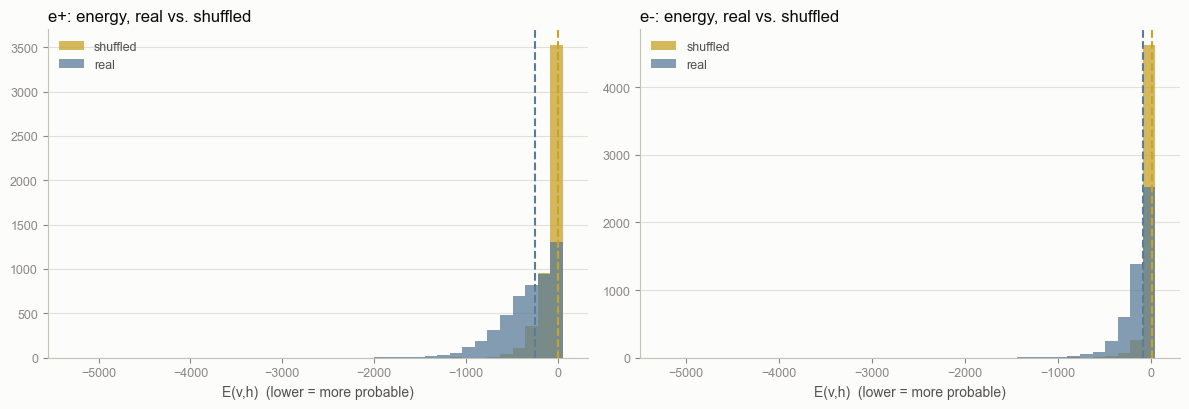

In [5]:
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
REAL_COLOR, SHUF_COLOR = "#5b7c99", "#c9a227"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), facecolor=SURFACE)
for ax, name, E_real, E_shuf in [
    (axes[0], "e+", E_real_plus, E_shuf_plus),
    (axes[1], "e-", E_real_minus, E_shuf_minus),
]:
    ax.set_facecolor(SURFACE)
    bins = np.linspace(min(E_real.min(), E_shuf.min()), max(E_real.max(), E_shuf.max()), 40)
    ax.hist(E_shuf, bins=bins, color=SHUF_COLOR, alpha=0.75, label="shuffled", zorder=3)
    ax.hist(E_real, bins=bins, color=REAL_COLOR, alpha=0.75, label="real", zorder=4)
    ax.axvline(np.median(E_real), color=REAL_COLOR, linewidth=1.5, linestyle="--", zorder=5)
    ax.axvline(np.median(E_shuf), color=SHUF_COLOR, linewidth=1.5, linestyle="--", zorder=5)
    ax.set_title(f"{name}: energy, real vs. shuffled", color=INK_PRIMARY, fontsize=12, loc="left")
    ax.set_xlabel("E(v,h)  (lower = more probable)", color=INK_SECONDARY, fontsize=10)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
    legend = ax.legend(frameon=False, fontsize=9, loc="upper left")
    for text in legend.get_texts():
        text.set_color(INK_SECONDARY)

plt.tight_layout()
plt.savefig(out_dir / "energy_real_vs_shuffled_5k.png", dpi=150, facecolor=SURFACE)
plt.show()

## Part 3 — Retrain both channels WITH visible bias `a`

Parts 0-2 above used the actual, already-trained `e₊`/`e₋` weights, which have no visible bias (confirmed by reading `train_rbm` in 13b/19 -- only `W` and `b_h` exist there). The full energy function,

$$E(v,h) = -a^\top v - b_h^\top h - v^\top W h$$

requires a real visible bias term `a`. This isn't a formula fix -- it changes what gets learned, so both channels are retrained here, from scratch, with `a` added to the model and its own CD-1 update rule. Saved under new filenames (`*_visbias_5k.npy`) so the original no-bias weights (used throughout notebooks 17/18/19/20/21) are untouched.

In [ ]:
def expand_mask_batch(m_movies, k):
    return np.repeat(m_movies, k, axis=1)


def train_rbm_full(X, M_movies, n_hidden, seed, channel_name, k_expand=1):
    """Masked CD-1, WITH visible bias a (unlike the original train_rbm in 13b/19)."""
    rng = np.random.default_rng(seed)
    n_samples, n_visible = X.shape

    W = rng.normal(0.0, 0.01, size=(n_visible, n_hidden)).astype(np.float64)
    a = np.zeros(n_visible, dtype=np.float64)
    b_h = np.zeros(n_hidden, dtype=np.float64)

    print(f"\n=== Training {channel_name} (with visible bias) ===  samples={n_samples}, visible={n_visible}, hidden={n_hidden}")
    print(f"  lr={LR}, batch={BATCH_SIZE}, epochs={EPOCHS}, seed={seed}, k_expand={k_expand}", flush=True)
    t0_all = time.time()

    for epoch in range(EPOCHS):
        t0 = time.time()
        epoch_delta_W = np.zeros_like(W)
        epoch_delta_a = np.zeros_like(a)
        order = rng.permutation(n_samples)

        for start in range(0, n_samples, BATCH_SIZE):
            idx = order[start:start + BATCH_SIZE]
            v_data = np.asarray(X[idx])
            m_batch = M_movies[idx]
            if k_expand > 1:
                m_batch = expand_mask_batch(m_batch, k_expand)
            m_batch = np.asarray(m_batch, dtype=X.dtype)
            bs = v_data.shape[0]

            h_prob = sigmoid(v_data @ W + b_h)
            h_data = (rng.random(h_prob.shape) < h_prob).astype(np.float64)

            v_recon_prob = sigmoid(h_data @ W.T + a) * m_batch
            v_recon = (rng.random(v_recon_prob.shape) < v_recon_prob).astype(np.float64) * m_batch

            h_recon_prob = sigmoid(v_recon @ W + b_h)
            h_recon = (rng.random(h_recon_prob.shape) < h_recon_prob).astype(np.float64)

            pos = v_data.T @ h_data
            neg = v_recon.T @ h_recon
            epoch_delta_W += LR * (pos - neg) / bs
            epoch_delta_a += LR * (v_data.mean(axis=0) - v_recon_prob.mean(axis=0))
            b_h += LR * (h_prob.mean(axis=0) - h_recon_prob.mean(axis=0))

        W += epoch_delta_W
        a += epoch_delta_a
        dt = time.time() - t0
        ep = epoch + 1
        if ep in (1, 25, EPOCHS):
            print(f"  Epoch {ep:02d} | wall {dt:.1f}s", flush=True)
        if ep == 1:
            print(f"  est. full {EPOCHS} epochs ~= {dt * EPOCHS / 60:.1f} min", flush=True)

    print(f"  Done in {(time.time()-t0_all)/60:.1f} min")
    return W, a, b_h


N_HIDDEN, LR, BATCH_SIZE, EPOCHS, INIT_SEED = 128, 0.01, 500, 50, 42

print("Retraining e+ WITH visible bias ...")
W_plus_vb, a_plus_vb, bh_plus_vb = train_rbm_full(channelB1.reshape(n_users, -1), mask, N_HIDDEN, INIT_SEED, "e+ (visbias)", k_expand=K)
np.save(proc / "rbmB1_weights_visbias_5k.npy", W_plus_vb)
np.save(proc / "rbmB1_bias_visible_visbias_5k.npy", a_plus_vb)
np.save(proc / "rbmB1_bias_hidden_visbias_5k.npy", bh_plus_vb)

print("\nRetraining e- WITH visible bias ...")
W_minus_vb, a_minus_vb, bh_minus_vb = train_rbm_full(channelDminus.reshape(n_users, -1), mask, N_HIDDEN, INIT_SEED, "e- (visbias)", k_expand=K)
np.save(proc / "rbmDminus_weights_visbias_5k.npy", W_minus_vb)
np.save(proc / "rbmDminus_bias_visible_visbias_5k.npy", a_minus_vb)
np.save(proc / "rbmDminus_bias_hidden_visbias_5k.npy", bh_minus_vb)

print("\nSaved *_visbias_5k.npy for both channels (original no-bias weights untouched).")